In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [88]:
root_data = Path("./data")
processed_dir = root_data / "processed"

keywords = ["data", "queich", "pet"]
csv_paths = {
    f.stem: f for f in root_data.rglob("*.csv") 
    if any(k in f.name for k in keywords)
    }

subset_date = "2005-01-01"

Saved dataframe to data\processed\discharge_queich_siebeldingen.csv!


<Axes: xlabel='date'>

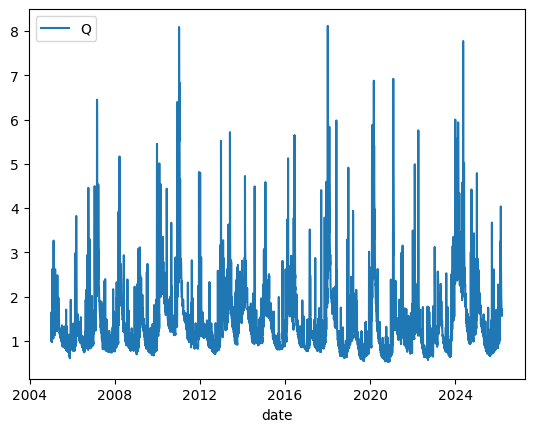

In [103]:
# --- Discharge ---
def process_discharge_data(
    path: str | Path,
    output_dir: str | Path | None = None,
    filename: str | None = "discharge_queich_siebeldingen"
    ) -> pd.DataFrame:
    
    df = pd.read_csv(path, sep=",", decimal=",")
    
    # Subset weird df for discharge and reset index
    df = df[df["Parameter"] == "Abfluss am Pegel"]
    df = df.reset_index(drop=True)

    # Create subset of copy
    df = df[["Datum", "Wert"]].copy()
    df.columns = ["date", "Q"]

    # To datetime and subset
    df["date"] = pd.to_datetime(df["date"], format="%d.%m.%Y")
    df = df[df["date"] > subset_date]
    df["date"] = df["date"].dt.date
    
    # Clean index and set date as index
    df = df.sort_values(by="date")
    df = df.reset_index(drop=True)
    df = df.set_index("date")
    
    if output_dir:
        output_path = Path(output_dir) / f"{filename}.csv"
        df.to_csv(output_path, sep=",")
        print(f"Saved dataframe to {output_path}!")
        
    return df

# Read discharge data
discharge_path = csv_paths["abfluss_queich_siebeldingen"]

# Process and plot discharge data
df_discharge = process_discharge_data(
    path=discharge_path,
    output_dir=processed_dir
    )

df_discharge.plot()

<Axes: xlabel='date'>

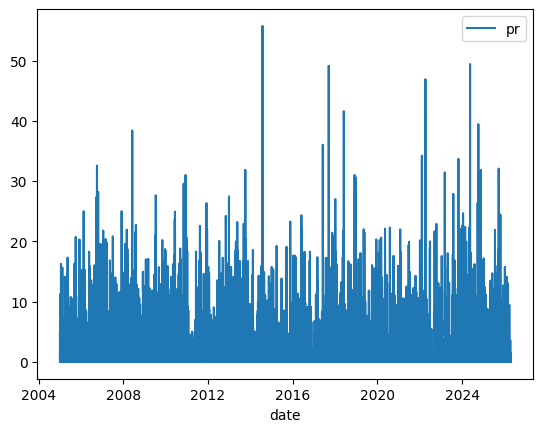

In [104]:
# --- Hyras precipitation ---
hyras_path = csv_paths["precip_mean_queich_watershed"]
df_precip = pd.read_csv(filepath_or_buffer=hyras_path, sep=",")

df_precip["date"] = pd.to_datetime(df_precip["date"], format="%Y-%m-%d %H:%M:%S")
df_precip = df_precip[df_precip["date"] > subset_date]
df_precip["date"] = df_precip["date"].dt.date

df_precip = df_precip.reset_index(drop=True)
df_precip = df_precip.set_index("date")
df_precip.plot()

<Axes: xlabel='date'>

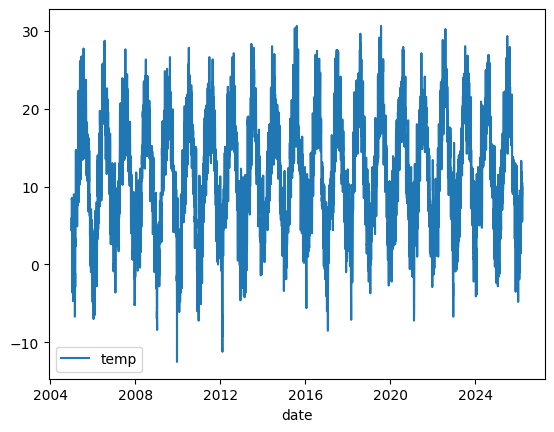

In [171]:
temp_path = csv_paths["data_OBS_DEU_P1D_T2M_377"]


df_temp = pd.read_csv(filepath_or_buffer=temp_path, sep=",", index_col=False)
df_temp = df_temp[["Zeitstempel", "Wert"]]

df_temp.columns = ["date", "temp"]

df_temp["date"] = pd.to_datetime(df_temp["date"], format="%Y-%m-%d")
df_temp = df_temp[df_temp["date"] > subset_date]
df_temp["date"] = df_temp["date"].dt.date

df_temp = df_temp.set_index("date")
df_temp.plot()

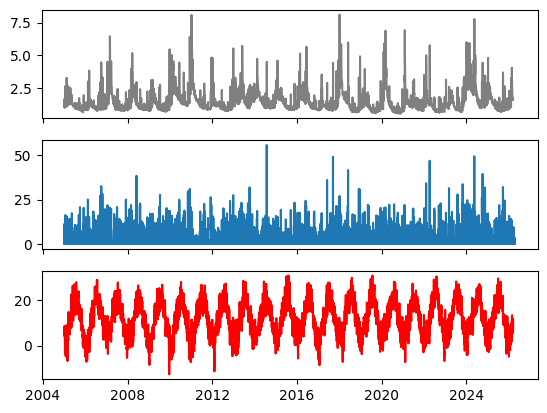

In [176]:
# Check
fig, axs = plt.subplots(nrows=3, sharex=True)
axs[0].plot(df_discharge, color="grey")
axs[1].plot(df_precip)
axs[2].plot(df_temp, color = "red")
plt.show()

In [222]:
dfs = [
    df_discharge,
    df_precip,
    df_temp
    ]

# dfs = [df.set_index("date") for df in dfs]    
# col_names = ["Q", "temp_bb", "precip_bb", "pet_bb"]

df_all = pd.concat(dfs, axis=1)
# df_all.columns = col_names
df_all

,Q,pr,temp
date,,,
2005-01-02,1.2105,0.251031,5.9
2005-01-03,0.9885,1.228866,4.3
2005-01-04,1.0754,0.023711,5.8
2005-01-05,1.1046,11.257732,4.7
2005-01-06,1.6392,0.173711,7.7
...,...,...,...
2026-04-16,NaN,0.000515,NaN
2026-04-17,NaN,0.000000,NaN
2026-04-18,NaN,1.339175,NaN


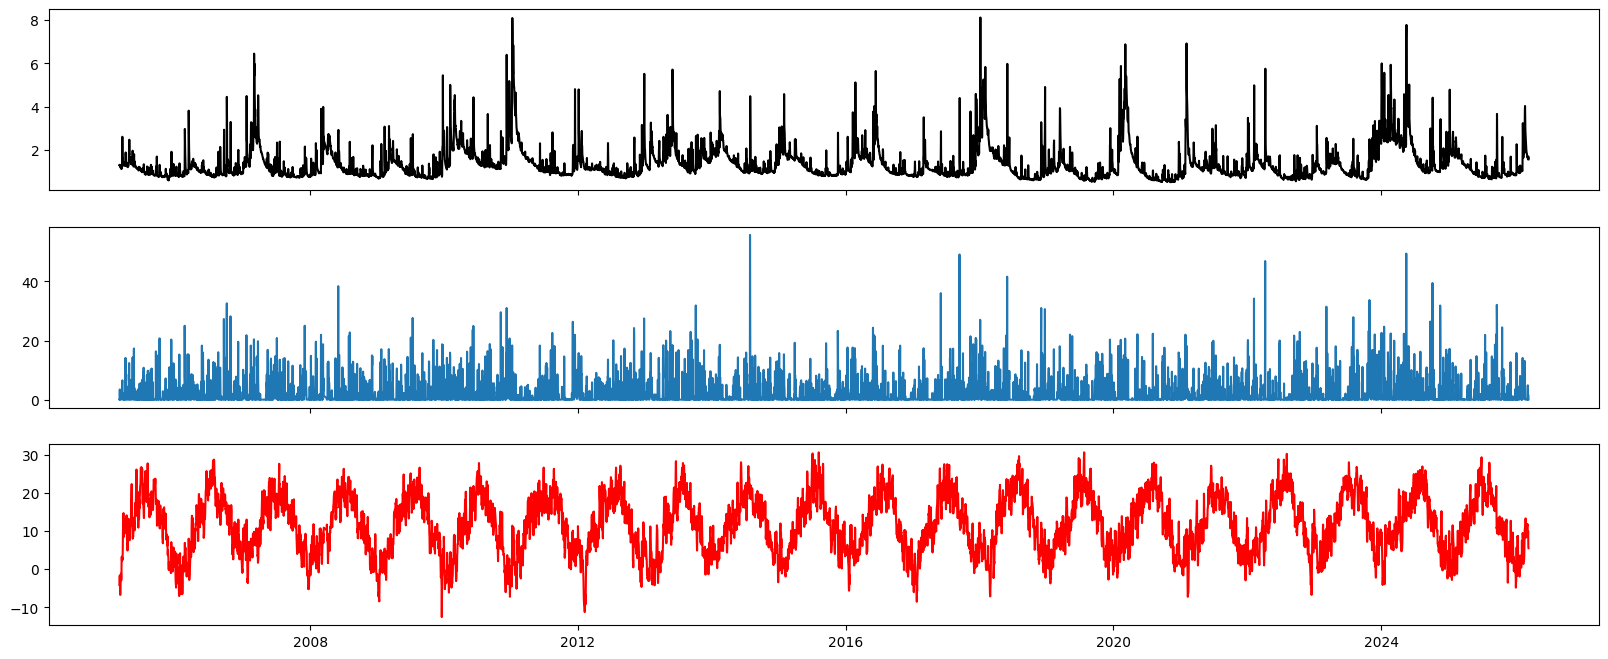

In [212]:
fig, axs = plt.subplots(nrows=3, figsize=(20, 8), sharex=True)

axs[0].plot(df_all["Q"], color = "black")
axs[1].plot(df_all["pr"])
axs[2].plot(df_all["temp"], color="red")

plt.show()

In [183]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

##### Add date transform, lag and sum to data

In [ ]:
df_all.index = pd.to_datetime(df_all.index)

# Add sin cos date transform to data
df_all["doy_sin"] = np.sin(2*np.pi * df_all.index.dayofyear/365)
df_all["doy_cos"] = np.cos(2*np.pi * df_all.index.dayofyear/365)


for col in df_all.columns:
    if "pr" in col or "temp" in col or "pet" in col:
        for lag in range(1, 28):
            df_all[f"{col}_{lag}"] = df_all[col].shift(lag)
    
    if "pr" in col:
        for d in [3, 7, 14, 21, 28, 56]:
            df_all[f"{col}_sum_{d}"] = df_all[col].rolling(d).sum()

df_all["target"] = df_all["Q"].shift(-1)

df_all.dropna(inplace=True)

df_all

,Q,pr,temp,doy_sin,doy_cos,pr_1,pr_2,pr_3,pr_4,pr_5,...,temp_19,temp_20,temp_21,temp_22,temp_23,temp_24,temp_25,temp_26,temp_27,target
date,,,,,,,,,,,,,,,,,,,,,
2005-02-26,1.2734,3.456186,-1.6,0.831171,0.556017,0.000000,0.041753,0.214948,2.757216,7.307216,...,-0.7,-2.3,-0.6,2.8,4.4,3.6,3.1,0.4,-4.1,1.2969
2005-02-27,1.2969,0.000000,-3.5,0.840618,0.541628,3.456186,0.000000,0.041753,0.214948,2.757216,...,1.4,-0.7,-2.3,-0.6,2.8,4.4,3.6,3.1,0.4,1.2099
2005-02-28,1.2099,0.000000,-6.7,0.849817,0.527078,0.000000,3.456186,0.000000,0.041753,0.214948,...,2.5,1.4,-0.7,-2.3,-0.6,2.8,4.4,3.6,3.1,1.2083
2005-03-01,1.2083,0.014433,-6.7,0.858764,0.512371,0.000000,0.000000,3.456186,0.000000,0.041753,...,5.0,2.5,1.4,-0.7,-2.3,-0.6,2.8,4.4,3.6,1.2211
2005-03-02,1.2211,0.000000,-4.3,0.867456,0.497513,0.014433,0.000000,0.000000,3.456186,0.000000,...,6.5,5.0,2.5,1.4,-0.7,-2.3,-0.6,2.8,4.4,1.2191
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-12,1.6823,0.000000,8.6,0.939856,0.341571,4.847938,0.139175,0.205155,0.000000,0.000000,...,8.1,3.8,2.5,2.3,4.5,5.6,1.4,3.8,7.6,1.5824
2026-03-13,1.5824,1.735052,10.0,0.945596,0.325342,0.000000,4.847938,0.139175,0.205155,0.000000,...,10.1,8.1,3.8,2.5,2.3,4.5,5.6,1.4,3.8,1.7092
2026-03-14,1.7092,0.979381,5.9,0.951057,0.309017,1.735052,0.000000,4.847938,0.139175,0.205155,...,10.7,10.1,8.1,3.8,2.5,2.3,4.5,5.6,1.4,1.5798


##### Split data

In [226]:
def split_date(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Performs a 70, 20, 10 split of the dataframe"""


# 70 / 20 / 10 split
train_idx = int(len(df_all) * 0.6)
val_idx = train_idx + int(len(df_all) * 0.2)

df_train = df_all.iloc[:train_idx]
df_val = df_all.iloc[train_idx:val_idx]
df_test = df_all.iloc[val_idx:]

print(f"Full size: {len(df_all)}")
print(f"Train size: {len(df_train)}")
print(f"Val size: {len(df_val)}")
print(f"Test size: {len(df_test)}")

Full size: 7660
Train size: 4596
Val size: 1532
Test size: 1532


In [227]:
skipcols = ["target", "date", "Q"]
feature_cols = [col for col in df_all.columns if col not in skipcols]
print(feature_cols)

X_train = df_train[feature_cols]
y_train = df_train["target"]

X_val = df_val[feature_cols]
y_val = df_val["target"]

X_test = df_test[feature_cols]
y_test = df_test["target"]

['pr', 'temp', 'doy_sin', 'doy_cos', 'pr_1', 'pr_2', 'pr_3', 'pr_4', 'pr_5', 'pr_6', 'pr_7', 'pr_8', 'pr_9', 'pr_10', 'pr_11', 'pr_12', 'pr_13', 'pr_14', 'pr_15', 'pr_16', 'pr_17', 'pr_18', 'pr_19', 'pr_20', 'pr_21', 'pr_22', 'pr_23', 'pr_24', 'pr_25', 'pr_26', 'pr_27', 'pr_sum_3', 'pr_sum_7', 'pr_sum_14', 'pr_sum_21', 'pr_sum_28', 'pr_sum_56', 'temp_1', 'temp_2', 'temp_3', 'temp_4', 'temp_5', 'temp_6', 'temp_7', 'temp_8', 'temp_9', 'temp_10', 'temp_11', 'temp_12', 'temp_13', 'temp_14', 'temp_15', 'temp_16', 'temp_17', 'temp_18', 'temp_19', 'temp_20', 'temp_21', 'temp_22', 'temp_23', 'temp_24', 'temp_25', 'temp_26', 'temp_27']


##### Train model

In [228]:
model = XGBRegressor(
    n_estimators=10000,
    max_depth=3,
    learning_rate=0.001,
    # subsample=0.8,
    # colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    early_stopping_rounds=20
)

In [229]:
model.fit(
    X_train, 
    y_train,
    eval_set=[(X_val, y_val)],
    )

[0]	validation_0-rmse:0.91822
[1]	validation_0-rmse:0.91776
[2]	validation_0-rmse:0.91731
[3]	validation_0-rmse:0.91685
[4]	validation_0-rmse:0.91640
[5]	validation_0-rmse:0.91594
[6]	validation_0-rmse:0.91549
[7]	validation_0-rmse:0.91504
[8]	validation_0-rmse:0.91459
[9]	validation_0-rmse:0.91414
[10]	validation_0-rmse:0.91372
[11]	validation_0-rmse:0.91327
[12]	validation_0-rmse:0.91286
[13]	validation_0-rmse:0.91241
[14]	validation_0-rmse:0.91199
[15]	validation_0-rmse:0.91155
[16]	validation_0-rmse:0.91114
[17]	validation_0-rmse:0.91069
[18]	validation_0-rmse:0.91025
[19]	validation_0-rmse:0.90984
[20]	validation_0-rmse:0.90939
[21]	validation_0-rmse:0.90898
[22]	validation_0-rmse:0.90854
[23]	validation_0-rmse:0.90814
[24]	validation_0-rmse:0.90770
[25]	validation_0-rmse:0.90729
[26]	validation_0-rmse:0.90685
[27]	validation_0-rmse:0.90644
[28]	validation_0-rmse:0.90601
[29]	validation_0-rmse:0.90560
[30]	validation_0-rmse:0.90517
[31]	validation_0-rmse:0.90476
[32]	validation_0-

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,20
,enable_categorical,False
,eval_metric,None


RMSE: 0.458


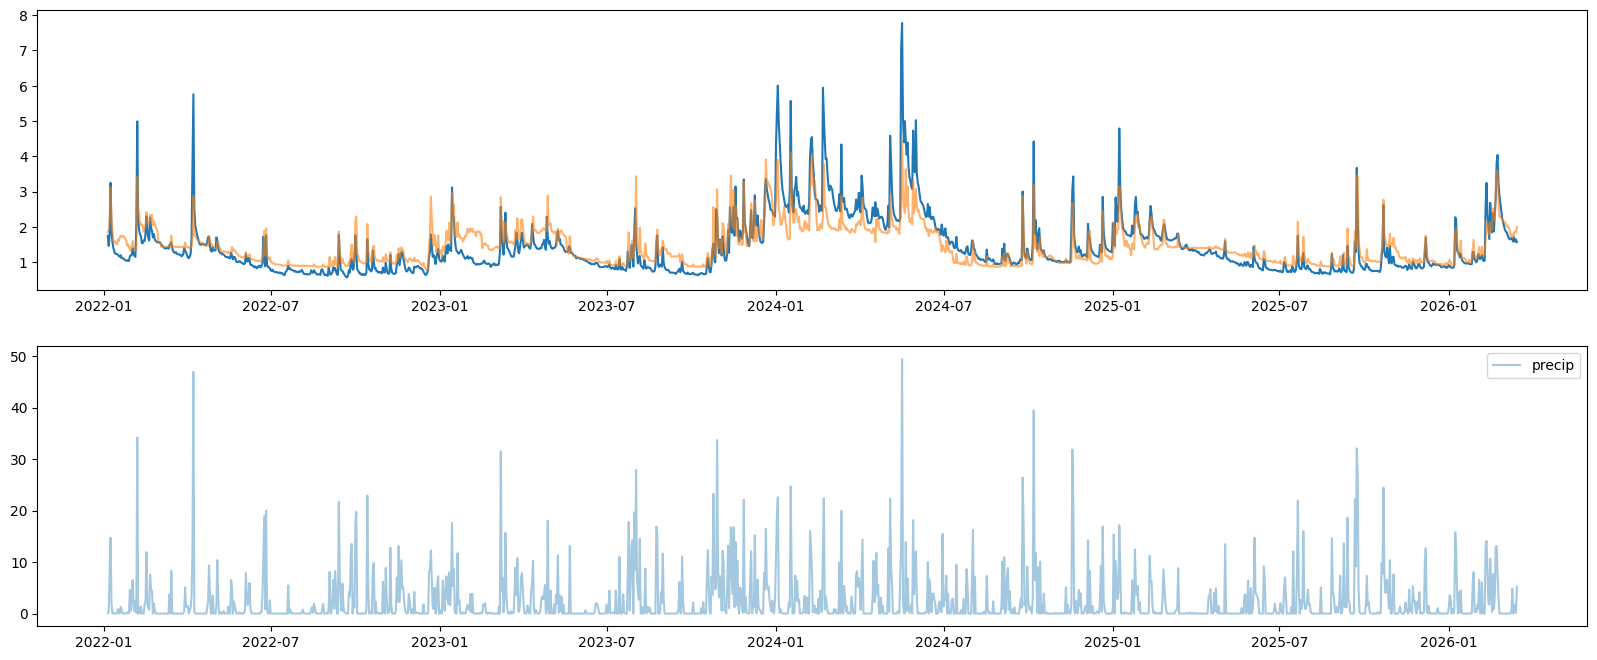

In [230]:
test_set = (X_test, y_test)

y_pred = model.predict(test_set[0])

rmse = np.sqrt(mean_squared_error(test_set[1], y_pred))
print(f"RMSE: {rmse:.3f}")

fig, axs = plt.subplots(nrows=2, figsize=(20,8))

axs[0].plot(test_set[1].index, test_set[1], label="Observed")
axs[0].plot(test_set[1].index, y_pred, label="Predicted", alpha=0.6)
axs[1].plot(test_set[1].index, test_set[0]["pr"], label="precip", alpha=0.4)

plt.legend()
plt.show()